In [1]:
import requests

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = requests.get(url).text

print(f"Lunghezza del dataset: {len(text)} caratteri")
print('-'*100)
print(text[:200]) # Un piccolo assaggio

Lunghezza del dataset: 1115394 caratteri
----------------------------------------------------------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [6]:
int2char

{0: '\n',
 1: ' ',
 2: '!',
 3: '$',
 4: '&',
 5: "'",
 6: ',',
 7: '-',
 8: '.',
 9: '3',
 10: ':',
 11: ';',
 12: '?',
 13: 'A',
 14: 'B',
 15: 'C',
 16: 'D',
 17: 'E',
 18: 'F',
 19: 'G',
 20: 'H',
 21: 'I',
 22: 'J',
 23: 'K',
 24: 'L',
 25: 'M',
 26: 'N',
 27: 'O',
 28: 'P',
 29: 'Q',
 30: 'R',
 31: 'S',
 32: 'T',
 33: 'U',
 34: 'V',
 35: 'W',
 36: 'X',
 37: 'Y',
 38: 'Z',
 39: 'a',
 40: 'b',
 41: 'c',
 42: 'd',
 43: 'e',
 44: 'f',
 45: 'g',
 46: 'h',
 47: 'i',
 48: 'j',
 49: 'k',
 50: 'l',
 51: 'm',
 52: 'n',
 53: 'o',
 54: 'p',
 55: 'q',
 56: 'r',
 57: 's',
 58: 't',
 59: 'u',
 60: 'v',
 61: 'w',
 62: 'x',
 63: 'y',
 64: 'z'}

In [2]:
# Creiamo il vocabolario (tutti i caratteri unici)
chars = sorted(list(set(text)))
vocab_size = len(chars)

# Mapping: carattere <-> intero
char2int = {ch: i for i, ch in enumerate(chars)}
int2char = {i: ch for i, ch in enumerate(chars)}

# Codifichiamo l'intero dataset
encoded_text = [char2int[ch] for ch in text]
print(text[:50])
encoded_text[:50]

First Citizen:
Before we proceed any further, hear


[18,
 47,
 56,
 57,
 58,
 1,
 15,
 47,
 58,
 47,
 64,
 43,
 52,
 10,
 0,
 14,
 43,
 44,
 53,
 56,
 43,
 1,
 61,
 43,
 1,
 54,
 56,
 53,
 41,
 43,
 43,
 42,
 1,
 39,
 52,
 63,
 1,
 44,
 59,
 56,
 58,
 46,
 43,
 56,
 6,
 1,
 46,
 43,
 39,
 56]

Creazione delle Sequenze
In un modello di linguaggio, l'input è una sequenza di caratteri e il target è la stessa sequenza spostata di un carattere a destra.

Esempio:

Input: SHAKESPEAR

Target: HAKESPEARE

Spezzettiamo il dataset in frammenti di lunghezza 100

In [8]:
encoded_text[:1000]

[18,
 47,
 56,
 57,
 58,
 1,
 15,
 47,
 58,
 47,
 64,
 43,
 52,
 10,
 0,
 14,
 43,
 44,
 53,
 56,
 43,
 1,
 61,
 43,
 1,
 54,
 56,
 53,
 41,
 43,
 43,
 42,
 1,
 39,
 52,
 63,
 1,
 44,
 59,
 56,
 58,
 46,
 43,
 56,
 6,
 1,
 46,
 43,
 39,
 56,
 1,
 51,
 43,
 1,
 57,
 54,
 43,
 39,
 49,
 8,
 0,
 0,
 13,
 50,
 50,
 10,
 0,
 31,
 54,
 43,
 39,
 49,
 6,
 1,
 57,
 54,
 43,
 39,
 49,
 8,
 0,
 0,
 18,
 47,
 56,
 57,
 58,
 1,
 15,
 47,
 58,
 47,
 64,
 43,
 52,
 10,
 0,
 37,
 53,
 59,
 1,
 39,
 56,
 43,
 1,
 39,
 50,
 50,
 1,
 56,
 43,
 57,
 53,
 50,
 60,
 43,
 42,
 1,
 56,
 39,
 58,
 46,
 43,
 56,
 1,
 58,
 53,
 1,
 42,
 47,
 43,
 1,
 58,
 46,
 39,
 52,
 1,
 58,
 53,
 1,
 44,
 39,
 51,
 47,
 57,
 46,
 12,
 0,
 0,
 13,
 50,
 50,
 10,
 0,
 30,
 43,
 57,
 53,
 50,
 60,
 43,
 42,
 8,
 1,
 56,
 43,
 57,
 53,
 50,
 60,
 43,
 42,
 8,
 0,
 0,
 18,
 47,
 56,
 57,
 58,
 1,
 15,
 47,
 58,
 47,
 64,
 43,
 52,
 10,
 0,
 18,
 47,
 56,
 57,
 58,
 6,
 1,
 63,
 53,
 59,
 1,
 49,
 52,
 53,
 61,
 1,
 15,
 39,
 47,

In [10]:
import torch
from torch.utils.data import Dataset, DataLoader

class ShakespeareDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        # Il numero totale di sequenze possibili
        return len(self.data) - self.seq_length 

    def __getitem__(self, idx):
        # Estraiamo la sequenza di input e quella di target
        input_seq = torch.tensor(self.data[idx : idx + self.seq_length])
        target_seq = torch.tensor(self.data[idx + 1 : idx + self.seq_length + 1])
        return input_seq, target_seq

# Parametri iper-didattici
SEQ_LENGTH = 100  # Lunghezza di ogni frammento di testo
BATCH_SIZE = 64   # Quante sequenze processare insieme

dataset = ShakespeareDataset(encoded_text, SEQ_LENGTH)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Test rapido: prendiamo un batch
inputs, targets = next(iter(dataloader))
print(f"Shape dell'input: {inputs.shape}") # Dovrebbe essere [64, 100]

Shape dell'input: torch.Size([64, 100])


## Definiamo il modello RNN

In [13]:
import torch
import torch.nn as nn

class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, n_layers):
        super(SimpleRNN, self).__init__()
        self.hidden_dim = hidden_dim

        # 1. Embedding: trasforma interi in vettori
        self.encoder = nn.Embedding(vocab_size, embedding_dim) #one hot ->  10000 -> 300 - EMB*one_hot

        # 2. RNN: il cuore del modello (dim di x, dim di a,num_layers (lo vedremo poi))
        self.rnn = nn.RNN(embedding_dim, hidden_dim, 1, batch_first=True)

        # 3. Decoder: mappa l'output della RNN sul vocabolario
        self.decoder = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        # x shape: (batch_size, seq_len)
        out = self.encoder(x)

        # out shape: (batch_size, seq_len, hidden_dim) ritorna le attivazioni di tutta la sequenza(out)e l'ultima attivazione (hidden)
        out, hidden = self.rnn(out, hidden)

        # Appiattiamo per il layer lineare
        out = out.reshape(-1, self.hidden_dim) # PASSO DA [Batch_Size, Seq_Len, Hidden_Dim] a [Batch_Size * Seq_Len, Hidden_Dim] 
        out = self.decoder(out)

        return out, hidden

    def init_hidden(self, batch_size):
        # Inizializza lo stato nascosto a zero
        return torch.zeros(1, batch_size, self.hidden_dim)

In [14]:
# Iperparametri
HIDDEN_DIM = 512
EMBEDDING_DIM = 64
LR = 0.0001
EPOCHS = 3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Inizializzazione
model = SimpleRNN(vocab_size, EMBEDDING_DIM, HIDDEN_DIM, 1 ).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
device

device(type='cuda')

In [26]:
def generate(model, start_str="r", length=300, temp=0.8):
    model.eval() # Modalità valutazione
    chars = [ch for ch in start_str]
    #Trasformo chars in interi e trasformo il vettore in matrice (la rete si aspetta una matrice)
    input_seq = torch.tensor([char2int[ch] for ch in chars]).unsqueeze(0).to(device)
    hidden = model.init_hidden(1).to(device)

    for _ in range(length):
        output, hidden = model(input_seq, hidden) #Calcolo la y^hat del modello e l'ultima attivazione (hidden)


        # 1. Dividiamo i logit per la temperatura
        logits = output[-1].data.div(temp)

        # 2. Applichiamo la Softmax completa (numeratore + denominatore)
        # dim=0 perché stiamo lavorando su un singolo vettore di caratteri
        probs = torch.softmax(logits, dim=0)

        # 3. Campioniamo dalla distribuzione risultante
        top_ch = torch.multinomial(probs, 1)[0] #Significa estrai un numero dalle probabilità che ti ho dato. [0] perchè l'output è un tensore di dimensione 1 quindi epr estrarre il valore devo estrarre l'indice [0]

        # Aggiungiamo il carattere predetto alla sequenza
        predicted_char = int2char[top_ch.item()]
        chars.append(predicted_char)

        # Il nuovo input è il carattere appena generato
        input_seq = torch.tensor([[top_ch]]).to(device)

    return "".join(chars)

In [27]:
generate(model)

'ress that will find much,\nThe crown to have since this good night.\n\nLADY ANNE:\nMy lord; he was courtised, to a fish and pointed\nFor that done my thoughts of her lift queen\nThe commo to your eyes Kate my lord, a parged to a happiess,\nAnd that the knee good wife time joys in the courtesure?\n\nELBOW:\nI t'

In [18]:
model.train()
for epoch in range(1, EPOCHS + 1):
    total_loss = 0

    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        # 1. Reset dei gradienti
        optimizer.zero_grad()

        # 2. Inizializziamo lo stato nascosto per questo batch
        hidden = model.init_hidden(inputs.size(0)).to(device)

        # 3. Forward pass
        output, hidden = model(inputs, hidden)

        # 4. Calcolo della perdita
        # NB: Dobbiamo "appiattire" il target per CrossEntropy
        loss = criterion(output, targets.view(-1))

        # 5. Backpropagation e aggiornamento
        loss.backward()

        # Gradient Clipping: evita che i gradienti "esplodano" (comune nelle RNN)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)

        optimizer.step()
# 
        total_loss += loss.item()

    print(f"Epoch: {epoch}/{EPOCHS} | Loss: {total_loss/len(dataloader):.4f}")

Epoch: 1/3 | Loss: 1.5631


KeyboardInterrupt: 

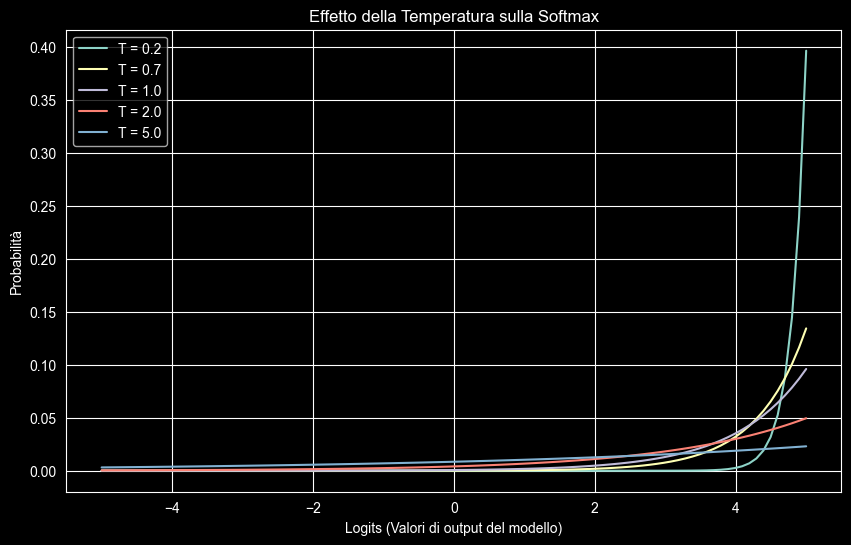

In [33]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x, temperature=1.0):
    e_x = np.exp((x - np.max(x)) / temperature)
    return e_x / e_x.sum()

# Creiamo un range di valori (i nostri logits)
logits = np.linspace(-5, 5, 100)
# Una semplice distribuzione a campana centrata sullo 0
probs_base = np.exp((logits / 1.0)**2)

temperatures = [0.2, 0.7, 1.0, 2.0, 5.0]

plt.figure(figsize=(10, 6))

for T in temperatures:
    # Applichiamo la temperatura e la softmax
    p = softmax(logits, temperature=T)
    plt.plot(logits, p, label=f'T = {T}')

plt.title('Effetto della Temperatura sulla Softmax')
plt.xlabel('Logits (Valori di output del modello)')
plt.ylabel('Probabilità')
plt.legend()
plt.grid(True)
plt.savefig('temperatura.png')
plt.show()